# LSTM vs GRU comparison for Sentiment Analysis

## Imports

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, GRU, Dense)
from sklearn.model_selection import train_test_split

## Data

In [2]:
texts = [
  "I love deep learning",
  "Artificial intelligence is amazing",
  "This course is excellent",
  "I am very happy today",
  "The movie was fantastic",
  "I hate this product",
  "This is very bad",
  "The service was terrible",
  "I am disappointed",
  "The experience was awful"
]

labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

### Tokenize

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
max_length = max([len(seq) for seq in sequences])
padded_sequences = pad_sequences(sequences, maxlen=max_length)

X = pad_sequences(sequences, maxlen=max_length)
y = np.array(labels)

X, y

(array([[ 0,  1,  8,  9, 10],
        [ 0, 11, 12,  2, 13],
        [ 0,  3, 14,  2, 15],
        [ 1,  6,  7, 16, 17],
        [ 0,  4, 18,  5, 19],
        [ 0,  1, 20,  3, 21],
        [ 0,  3,  2,  7, 22],
        [ 0,  4, 23,  5, 24],
        [ 0,  0,  1,  6, 25],
        [ 0,  4, 26,  5, 27]], dtype=int32),
 array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0]))

### Split the data

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Build LSTM model

In [35]:
model_lstm = Sequential([
    Embedding(input_dim=len(tokenizer.word_index) + 1,
              output_dim=100, input_length=max_length),
    LSTM(units=32),
    Dense(units=1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train model

In [36]:
history_lstm = model_lstm.fit(X_train, y_train,
                              epochs=5,
                              validation_split=0.2,
                              verbose=1)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1667 - loss: 0.6978 - val_accuracy: 0.0000e+00 - val_loss: 0.7006
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.5000 - loss: 0.6947 - val_accuracy: 0.0000e+00 - val_loss: 0.7011
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.5000 - loss: 0.6917 - val_accuracy: 0.0000e+00 - val_loss: 0.7016
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 1.0000 - loss: 0.6887 - val_accuracy: 0.0000e+00 - val_loss: 0.7021
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 1.0000 - loss: 0.6857 - val_accuracy: 0.0000e+00 - val_loss: 0.7026


In [37]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Plots the training (and validation) metrics from a Keras/TensorFlow history object.
    """
    # Find all metrics available in the history (e.g., 'loss', 'accuracy', etc.)
    metrics = [m for m in history.history.keys() if not m.startswith('val_')]

    # Determine the grid layout for subplots
    num_metrics = len(metrics)
    fig, axes = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 4))

    # Ensure axes is an array even if there's only 1 metric (like just 'loss')
    if num_metrics == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        # Plot training metric
        ax.plot(history.history[metric], label=f'Train {metric.capitalize()}', linewidth=2)

        # Plot validation metric if it exists
        val_metric = f'val_{metric}'
        if val_metric in history.history:
            ax.plot(history.history[val_metric], label=f'Val {metric.capitalize()}', linestyle='--', linewidth=2)

        # Formatting
        ax.set_title(f'Model {metric.capitalize()} over Epochs', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epochs', fontsize=10)
        ax.set_ylabel(metric.capitalize(), fontsize=10)
        ax.legend(loc='best')
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

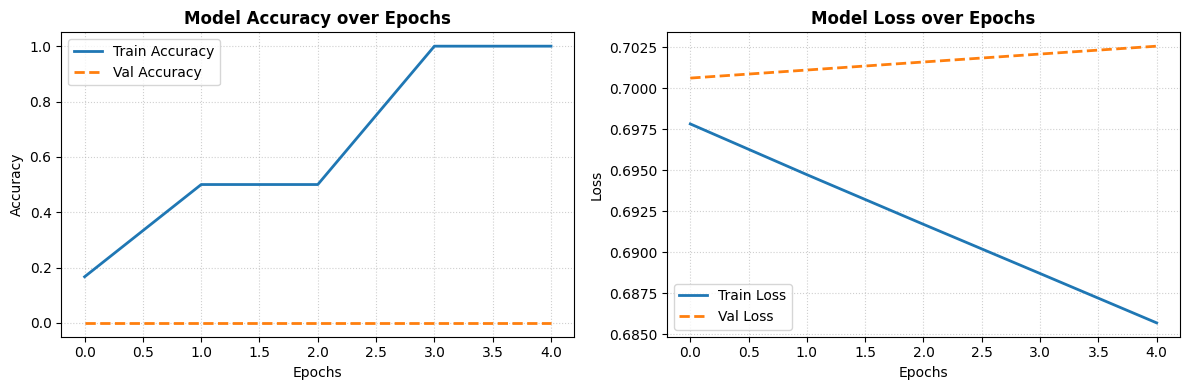

In [38]:
plot_training_history(history_lstm)

## Evaluation

In [39]:
y_proba = model_lstm.predict(X_test)
y_preds = np.round(y_proba).flatten()
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


array([0., 0.], dtype=float32)

In [40]:
model_lstm.evaluate(X_test, y_test, verbose=0)

[0.6894585490226746, 0.5]

In [41]:
y_test

array([0, 1])

## Build GRU model

In [49]:
(len(X[0]), 1)

(5, 1)

In [53]:
model_gru = Sequential([
    Embedding(input_dim=len(tokenizer.word_index) + 1,
              output_dim=100,
              input_length=max_length,
              ),
    GRU(units=32),
    Dense(units=1, activation='sigmoid')
])

# Compile
model_gru.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model_gru.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train model

In [43]:
history_gru = model_gru.fit(X_train, y_train,
                            epochs=5,
                            validation_split=0.2,
                            verbose=1)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.6920 - val_accuracy: 0.5000 - val_loss: 0.6956
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6667 - loss: 0.6860 - val_accuracy: 0.5000 - val_loss: 0.6964
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8333 - loss: 0.6802 - val_accuracy: 0.5000 - val_loss: 0.6971
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8333 - loss: 0.6743 - val_accuracy: 0.5000 - val_loss: 0.6979
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 1.0000 - loss: 0.6683 - val_accuracy: 0.5000 - val_loss: 0.6986


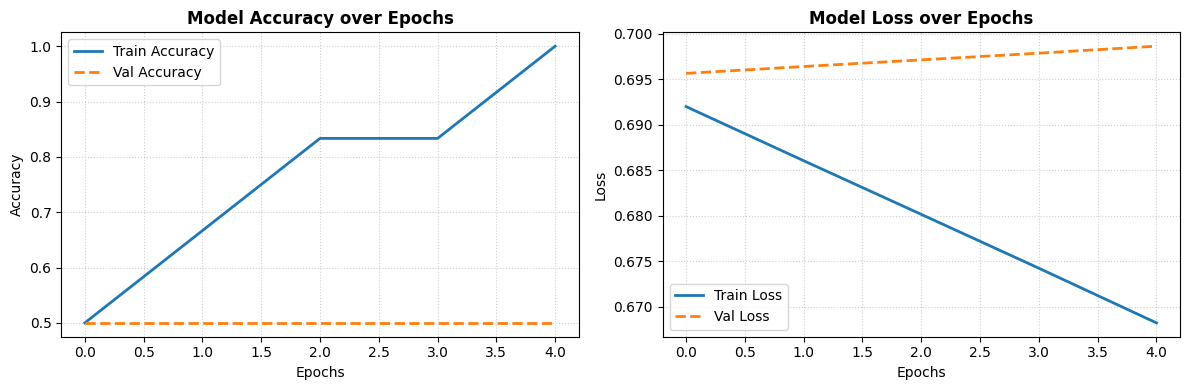

In [44]:
plot_training_history(history_gru)

## Evaluation

In [45]:
y_proba = model_gru.predict(X_test)
y_preds = np.round(y_proba).flatten()
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


array([1., 1.], dtype=float32)

In [46]:
model_gru.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.6858


[0.6858006119728088, 0.5]

In [47]:
y_test

array([0, 1])

## Model testing

In [54]:
text = 'I love artificial intelligence'
seq = tokenizer.texts_to_sequences([text])
padded_seq = pad_sequences(seq, maxlen=max_length)
model_lstm.predict(padded_seq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step


array([[0.49923295]], dtype=float32)

In [55]:
model_gru(padded_seq)

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.5026914]], dtype=float32)>